## **Project: Polynomial Regression**
---
### **Objective**
#### **Compare:**
- Linear Regression
- Polynomial Regression
---

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **Load Dataset**
---

In [51]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

### **Features & Target Selection**
---

In [52]:
Input = data.data
Output = data.target

df = pd.DataFrame(Input,columns=data.feature_names)
df["target"] = Output

X = df[["age","bmi"]]
y = df["target"]

X.shape

(442, 2)

### **Visualization**
---

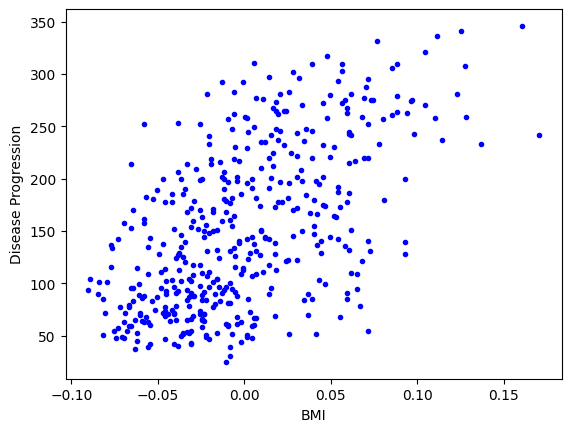

In [64]:
plt.plot(df['bmi'],df['target'],"b.")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.show()

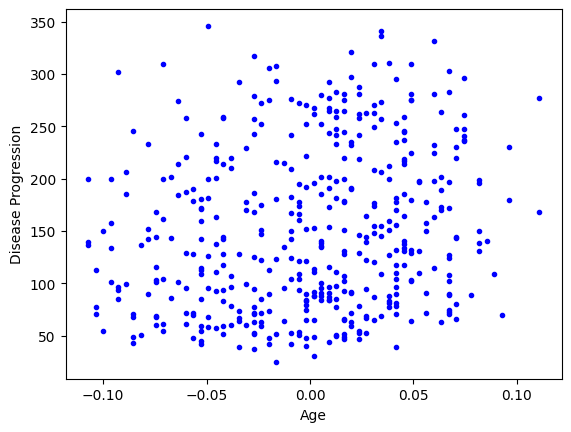

In [65]:
plt.plot(df["age"],df["target"],"b.")
plt.xlabel("Age")
plt.ylabel("Disease Progression")
plt.show()

### **Train / Test Split**
---

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
y_train.shape

(353,)

### **Linear Regression**
---

In [56]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

### **Polynomial Regression**
---

In [57]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly,y_train)

poly_y_pred = model.predict(X_test_poly)

### **Evaluation**
---

In [58]:
from sklearn.metrics import mean_squared_error,r2_score

print("Linear MSE: ",mean_squared_error(y_test,y_pred_lr))
print("Polynomial MSE: ",mean_squared_error(y_test,poly_y_pred))

print("Linear R2 Score: ",r2_score(y_test,y_pred_lr))
print("Polynomial R2 Score: ",r2_score(y_test,poly_y_pred))

Linear MSE:  4052.775428111814
Polynomial MSE:  4114.059953248346
Linear R2 Score:  0.235058635448385
Polynomial R2 Score:  0.22349148372350458


## **Visualization**
---

In [62]:
import numpy as np
import plotly.graph_objects as go

# Grid banate hain
bmi_range = np.linspace(X["bmi"].min(), X["bmi"].max(), 50)
age_range = np.linspace(X["age"].min(), X["age"].max(), 50)

bmi_grid, age_grid = np.meshgrid(bmi_range, age_range)

# 2 features combine
X_grid = np.c_[bmi_grid.ravel(), age_grid.ravel()]

# Polynomial transform
X_grid_poly = poly.transform(X_grid)

# Prediction
y_pred = model.predict(X_grid_poly)

# reshape for surface
y_pred = y_pred.reshape(bmi_grid.shape)

# 🎯 Plotly Figure
fig = go.Figure()

# Surface (model prediction)
fig.add_trace(go.Surface(
    x=bmi_grid,
    y=age_grid,
    z=y_pred,
    opacity=0.7
))

# Scatter (actual data)
fig.add_trace(go.Scatter3d(
    x=X["bmi"],
    y=X["age"],
    z=y,
    mode='markers'
))

# Labels
fig.update_layout(
    title="3D Polynomial Regression Surface",
    scene=dict(
        xaxis_title='BMI',
        yaxis_title='Age',
        zaxis_title='Target'
    )
)

fig.show()

c:\Users\Anas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
